# Project 1 — Regression
## Predict Song Popularity

Camilla Alves. Machine Learning for Marketing — NOVA IMS (2023).

---

### Summary

Regression project on the `songs_popularity.xlsx` dataset (18,835 songs, 15 features). The target is `song_popularity` on a 0-100 scale. Three algorithm families from the course are compared under CRISP-DM: Linear Regression, Decision Tree Regressor and MLPRegressor (Linear Neural Network).

The most robust model on the test set is the Decision Tree tuned with `GridSearchCV` (MAE 15.17, R² 0.018). Popularity is inherently hard to predict from audio features alone — the ceiling of any of the three models sits around R² ≈ 0.02 on unseen data. This is consistent with the correlation heatmap: no single feature correlates with popularity above 0.11 in absolute value.


## Business Understanding

### Overview

The marketing department of a record company wants a model that predicts the popularity of a song from its audio features. The predicted popularity will then be used to define the promotion budget allocated to each song — more budget goes to songs the model expects to perform well.

### Dataset description

| Feature | Description |
|---|---|
| `song_name` | Name of the song |
| `song_popularity` | Target — popularity of the song (0 to 100) |
| `song_duration_ms` | Duration in milliseconds |
| `acousticness` | 0 = fully electronic, 1 = fully acoustic |
| `originality` | Originality score (1 to 100). ~70% missing in the raw data |
| `danceability` | 0 = not suitable for dancing, 1 = very danceable |
| `energy` | 0 = calm, 1 = highly energetic |
| `instrumentalness` | 0 = many vocals, 1 = almost fully instrumental |
| `key` | Musical key (0 to 11) |
| `liveness` | 0 = studio, 1 = live recording |
| `loudness` | Overall volume in dB |
| `audio_mode` | 1 = major, 0 = minor |
| `speechiness` | 0 = instrumental, 1 = spoken word |
| `tempo` | Beats per minute |
| `time_signature` | Beats per measure (1 to 5) |
| `audio_valence` | 0 = negative emotion, 1 = positive emotion |


## Initializations and data loading

In [1]:
# Loading packages
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.feature_selection import RFECV
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, max_error,
)

from joblib import dump

RANDOM_STATE = 55
DATA_PATH = Path("../data/songs_popularity.xlsx")
MODEL_DIR = Path("../models"); MODEL_DIR.mkdir(exist_ok=True)
REPORT_DIR = Path("../reports"); REPORT_DIR.mkdir(exist_ok=True)

# Consistent visual language
COLOR_PRIMARY   = "#2C3E50"
COLOR_ACCENT    = "#C0392B"
COLOR_NEUTRAL   = "#7F8C8D"

sns.set_theme(style="whitegrid", context="notebook",
              rc={"axes.spines.top": False, "axes.spines.right": False,
                  "axes.grid.axis": "y", "grid.alpha": 0.25,
                  "axes.titleweight": "semibold", "axes.titlesize": 12,
                  "axes.labelsize": 10})
plt.rcParams["figure.dpi"] = 100


## Data understanding

In [2]:
# Loading the dataset and visualizing summary statistics
ds = pd.read_excel(DATA_PATH, engine="openpyxl")
ds.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18835 entries, 0 to 18834
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   song_name         18835 non-null  object 
 1   song_popularity   18835 non-null  int64  
 2   song_duration_ms  18835 non-null  int64  
 3   acousticness      18835 non-null  float64
 4   originality       5742 non-null   float64
 5   danceability      18835 non-null  float64
 6   energy            18835 non-null  float64
 7   instrumentalness  18829 non-null  float64
 8   key               18835 non-null  int64  
 9   liveness          18835 non-null  float64
 10  loudness          18835 non-null  float64
 11  audio_mode        18835 non-null  int64  
 12  speechiness       18835 non-null  float64
 13  tempo             18835 non-null  float64
 14  time_signature    18835 non-null  int64  
 15  audio_valence     18835 non-null  float64
dtypes: float64(10), int64(5), object(1)
memo

In [3]:
ds.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
song_name,18835,13070,Better,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
song_popularity,18835.0,NaN,NaN,NaN,52.991877,21.905654,0.0,40.0,56.0,69.0,100.0
song_duration_ms,18835.0,NaN,NaN,NaN,218211.587576,59887.540566,12000.0,184339.5,211306.0,242844.0,1799346.0
acousticness,18835.0,NaN,NaN,NaN,0.258539,0.288719,0.000001,0.0241,0.132,0.424,0.996
originality,5742.0,NaN,NaN,NaN,50.679032,29.07375,1.0,26.0,52.0,76.0,100.0
danceability,18835.0,NaN,NaN,NaN,0.633348,0.156723,0.0,0.533,0.645,0.748,0.987
energy,18835.0,NaN,NaN,NaN,0.644995,0.214101,0.00107,0.51,0.674,0.815,0.999
instrumentalness,18829.0,NaN,NaN,NaN,0.080157,0.264622,0.0,0.0,0.000011,0.00259,10.0
key,18835.0,NaN,NaN,NaN,5.289196,3.614595,0.0,2.0,5.0,8.0,11.0
liveness,18835.0,NaN,NaN,NaN,0.17965,0.143984,0.0109,0.0929,0.122,0.221,0.986


In [4]:
# Checking songs that are repeated the most
ds["song_name"].value_counts().head(15)


Better                                            21
FEFE (feat. Nicki Minaj & Murda Beatz)            19
MIA (feat. Drake)                                 18
Taki Taki (with Selena Gomez, Ozuna & Cardi B)    18
No Stylist                                        17
Promises (with Sam Smith)                         16
Electricity (with Dua Lipa)                       16
I Love It (& Lil Pump)                            16
Mo Bamba                                          16
Sunflower - Spider-Man: Into the Spider-Verse     16
Lullaby                                           15
Love Someone                                      14
Happier                                           14
Fall                                              14
Wake Up in the Sky                                14
Name: song_name, dtype: int64

In [5]:
# Show top rows
ds.head()


,song_name,song_popularity,song_duration_ms,acousticness,originality,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
0,Boulevard of Broken Dreams,73,262333,0.005520,NaN,0.496,0.682,0.000029,8,0.0589,-4.095,1,0.0294,167.060,4,0.474
1,In The End,66,216933,0.010300,NaN,0.542,0.853,0.000000,3,0.1080,-6.407,0,0.0498,105.256,4,0.370
2,Seven Nation Army,76,231733,0.008170,NaN,0.737,0.463,0.447000,0,0.2550,-7.828,1,0.0792,123.881,4,0.324
3,By The Way,74,216933,0.026400,NaN,0.451,0.970,0.003550,0,0.1020,-4.938,1,0.1070,122.444,4,0.198
4,How You Remind Me,56,223826,0.000954,NaN,0.447,0.766,0.000000,10,0.1130,-5.065,1,0.0313,172.011,4,0.574


In [6]:
# Confirm missing values per column
print(ds.isnull().sum())


song_name               0
song_popularity         0
song_duration_ms        0
acousticness            0
originality         13093
danceability            0
energy                  0
instrumentalness        6
key                     0
liveness                0
loudness                0
audio_mode              0
speechiness             0
tempo                   0
time_signature          0
audio_valence           0
dtype: int64


**Note.** Around 31% of songs share a name with at least one other song (some are true duplicates, some are covers or remixes). The variable `originality` has ~70% missing values and will be dropped in data preparation. `instrumentalness` has fewer than 1% missing and will be imputed.

### Target distribution

Understanding the target before modelling is essential. If `song_popularity` is heavily skewed or bimodal, the models will struggle in predictable ways.

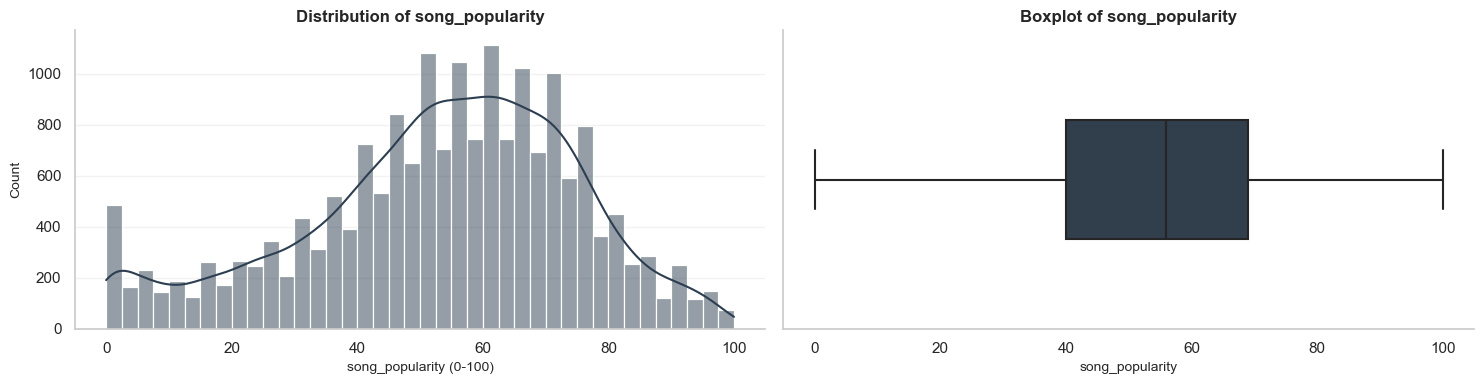

Mean: 52.99
Median: 56.00
Std: 21.91
Zeros (unrated?): 272 songs


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.histplot(ds["song_popularity"], bins=40, kde=True, ax=axes[0],
             color=COLOR_PRIMARY, edgecolor="white")
axes[0].set_title("Distribution of song_popularity")
axes[0].set_xlabel("song_popularity (0-100)")

sns.boxplot(x=ds["song_popularity"], ax=axes[1], color=COLOR_PRIMARY, width=0.4)
axes[1].set_title("Boxplot of song_popularity")

plt.tight_layout()
plt.show()

print(f"Mean: {ds['song_popularity'].mean():.2f}")
print(f"Median: {ds['song_popularity'].median():.2f}")
print(f"Std: {ds['song_popularity'].std():.2f}")
print(f"Zeros (unrated?): {(ds['song_popularity'] == 0).sum()} songs")


**Note.** The target is roughly bell-shaped and centered around 50-55, but with a visible cluster near zero. Those zero-popularity rows are unrated songs — they behave differently from the main distribution and pull the mean down. Any model will underperform in this region because the audio features do not distinguish "not yet released" from "released and unpopular".

### Feature distributions

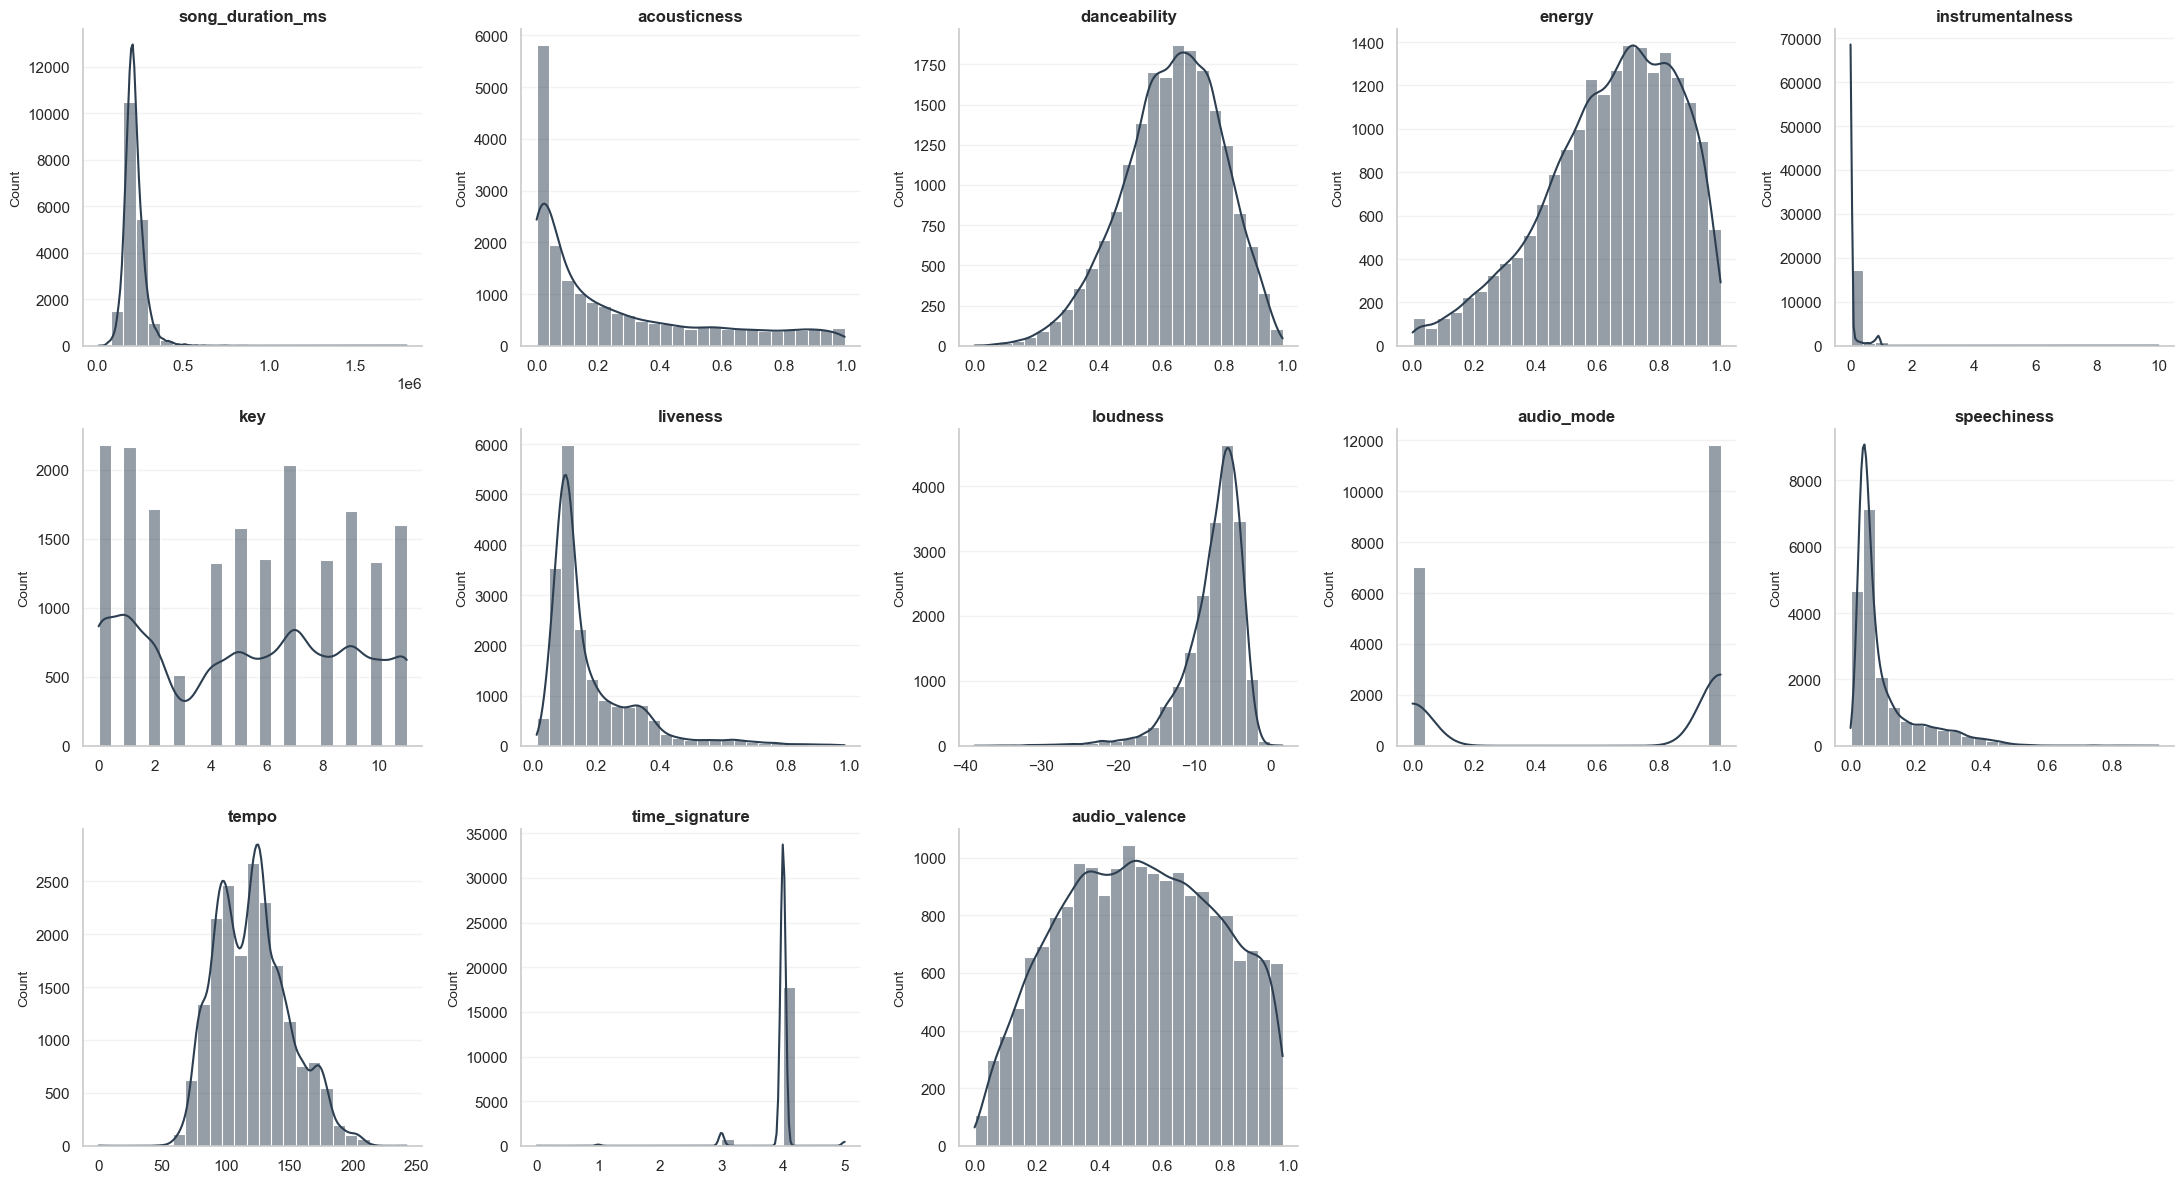

In [8]:
features_to_plot = ["song_duration_ms", "acousticness", "danceability", "energy",
                    "instrumentalness", "key", "liveness", "loudness", "audio_mode",
                    "speechiness", "tempo", "time_signature", "audio_valence"]

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.histplot(ds[col], bins=25, kde=True, ax=axes[i],
                 color=COLOR_PRIMARY, edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_xlabel("")

# Hide any unused axes
for j in range(len(features_to_plot), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


**Note.** Most audio features are bounded in [0, 1] and behave as expected: `energy` and `danceability` cluster around 0.5-0.8, `acousticness` skews toward zero (most tracks are electronic), `instrumentalness` is strongly right-skewed (most songs have vocals), and `key` is roughly uniform with slight peaks around C (0) and G (7). `tempo` is normally distributed around 120 BPM, which matches the typical range for pop music.

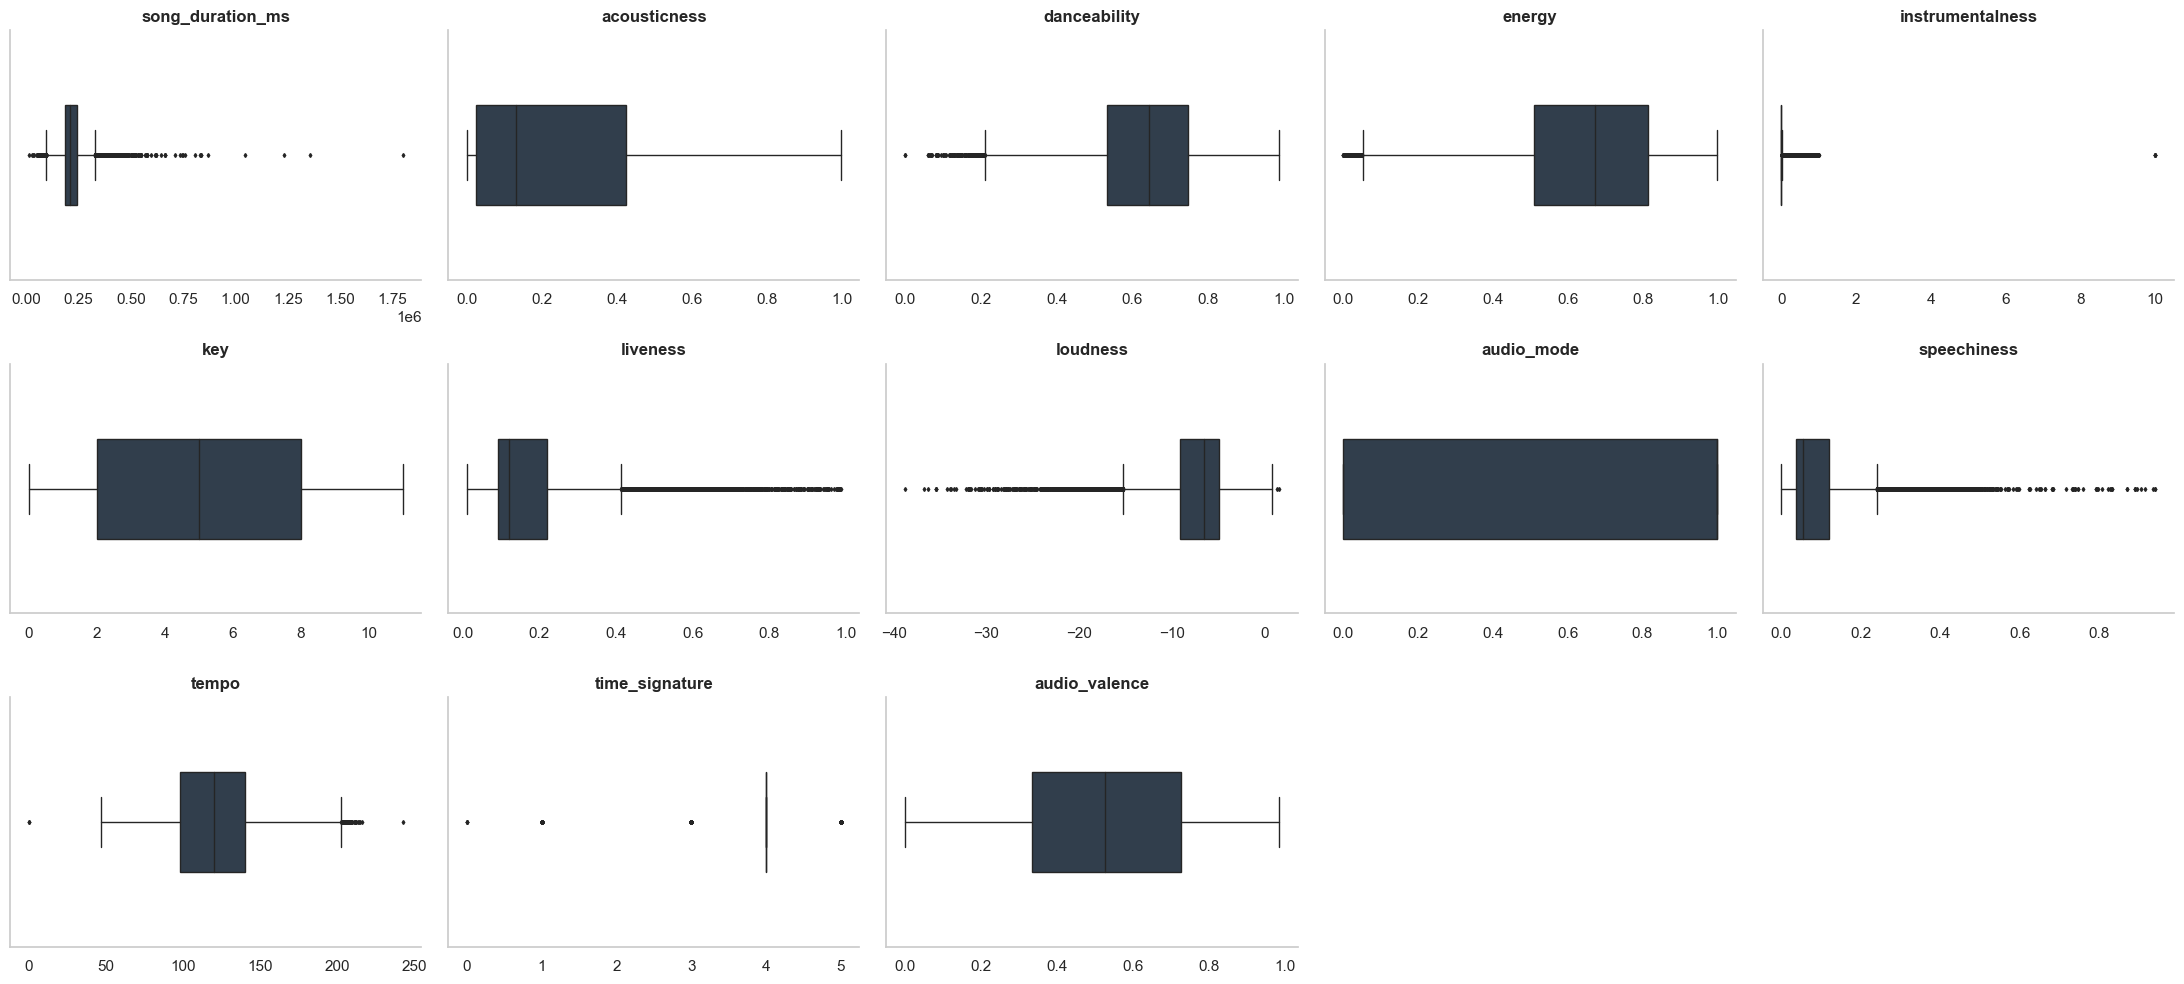

In [9]:
# Boxplots to identify outliers
fig, axes = plt.subplots(3, 5, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.boxplot(x=ds[col], ax=axes[i], color=COLOR_PRIMARY, width=0.4,
                fliersize=2, linewidth=1)
    axes[i].set_title(col)
    axes[i].set_xlabel("")

for j in range(len(features_to_plot), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


**Note.** Four variables show clear outliers: `song_duration_ms` (a few songs run more than 20 minutes), `instrumentalness` (a handful sit at exactly 10 — a data-entry anomaly given the expected 0-1 range), `loudness` (very quiet tracks below -25 dB), and `tempo` (a few tracks near zero BPM). These are handled in data preparation.

### Correlations

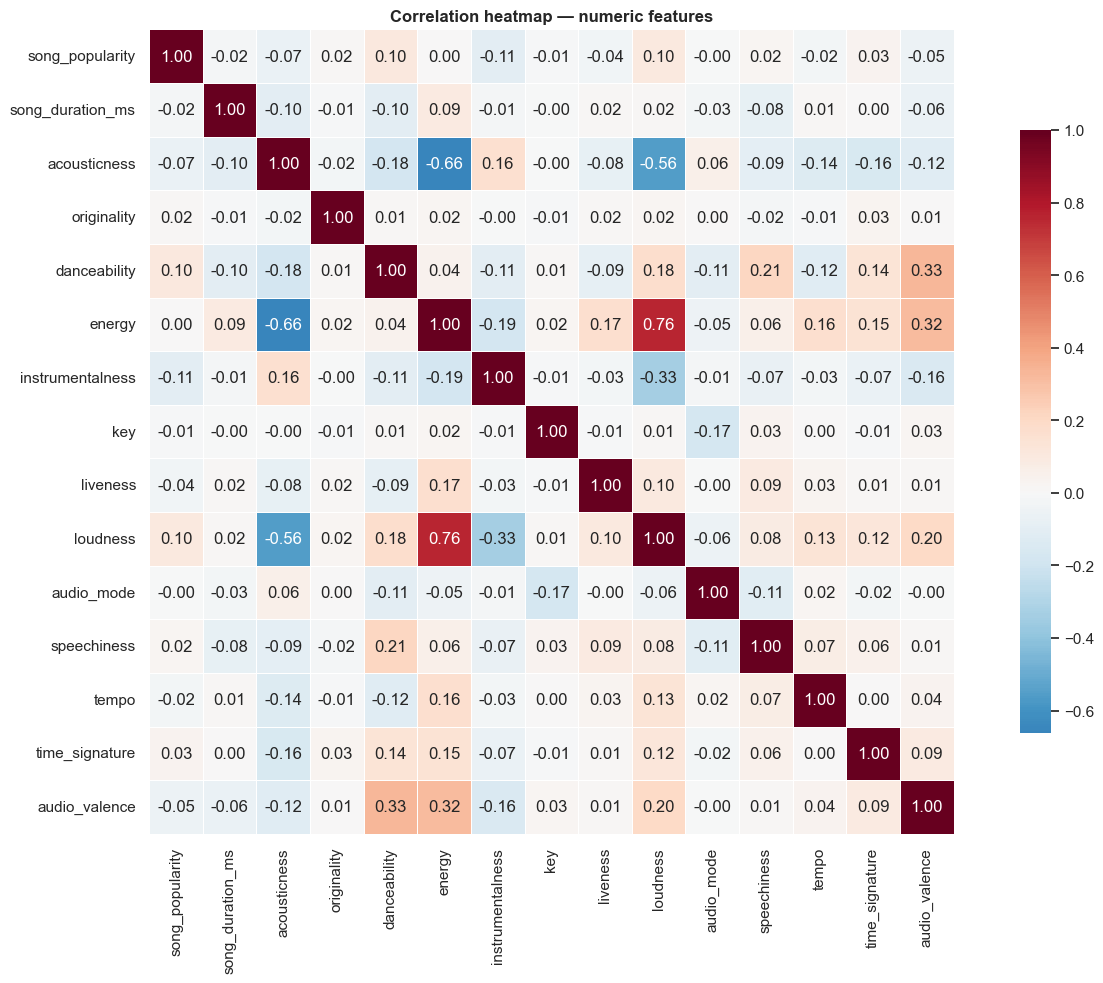

In [10]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(ds.select_dtypes(include=[np.number]).corr(),
            annot=True, cmap="RdBu_r", center=0, fmt=".2f",
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.75})
plt.title("Correlation heatmap — numeric features")
plt.tight_layout()
plt.show()


**Note.** Two observations matter for modelling:

- **Loudness and energy correlate strongly (~0.76).** In a linear regression this multicollinearity distorts coefficients and can flip their signs. One of the two should be dropped or a technique that handles collinearity (regularisation, PCA) applied. Here we keep both and flag the trade-off, since our brief is to compare the three classes of models exactly as taught in class.
- **No single feature correlates strongly with `song_popularity`.** The strongest linear correlations are around 0.10-0.11 in absolute value (instrumentalness, loudness, danceability). This tells us upfront that a linear model will have a near-zero R² on this problem — popularity is not a linear function of audio features alone.


## Data preparation

In [11]:
# Create a modeling dataset from the original
df = ds.copy(deep=True)


In [12]:
# Drop 'originality' — 70% of the column is missing
df = df.drop(columns=["originality"])

# Impute the small remaining gap in 'instrumentalness' with the median
df["instrumentalness"] = df["instrumentalness"].fillna(df["instrumentalness"].median())

# Drop full-duplicate rows
before = len(df)
df = df.drop_duplicates(keep=False)
print(f"Rows after dropping duplicates: {before} -> {len(df)}")


Rows after dropping duplicates: 18835 -> 12724


In [13]:
# Feature engineering — convert duration to minutes for readability
df["song_duration_min"] = df["song_duration_ms"] / 60000
df = df.drop(columns=["song_duration_ms"])

# song_name is high-cardinality and does not feed the model
df = df.drop(columns=["song_name"])

print(f"Missing values after preparation: {df.isnull().sum().sum()}")
df.describe().T


Missing values after preparation: 0


,count,mean,std,min,25%,50%,75%,max
song_popularity,12724.0,46.213691,19.495637,0.000000,35.000000,49.000000,60.000000,93.0000
acousticness,12724.0,0.278590,0.303922,0.000001,0.023400,0.146000,0.484000,0.9960
danceability,12724.0,0.620244,0.159032,0.000000,0.520000,0.631000,0.736000,0.9870
energy,12724.0,0.635139,0.226454,0.001630,0.485000,0.669000,0.818000,0.9990
instrumentalness,12724.0,0.105500,0.308086,0.000000,0.000000,0.000030,0.007963,10.0000
key,12724.0,5.308551,3.575843,0.000000,2.000000,5.000000,8.000000,11.0000
liveness,12724.0,0.180680,0.144647,0.010900,0.093200,0.122000,0.226000,0.9860
loudness,12724.0,-7.830997,4.142606,-38.768000,-9.619500,-6.878500,-5.043000,1.5850
audio_mode,12724.0,0.633920,0.481751,0.000000,0.000000,1.000000,1.000000,1.0000
speechiness,12724.0,0.098140,0.103305,0.000000,0.037000,0.053600,0.110000,0.9410


**Note.** `originality` is dropped because 70% missing means any imputation would fabricate most of the column. `instrumentalness` is imputed with the median (a robust statistic given the skew). `song_duration_ms` is converted to minutes and `song_name` is dropped because it has 13,070 unique values in 18,835 rows — too high-cardinality to encode usefully.

## Modeling

### Split, outlier removal on train only, and scaling

The order matters. If outliers are removed on the whole dataset before splitting, information from the test set leaks into what the model sees. The correct sequence is:

1. Split into train / test
2. Remove outliers using percentiles computed **only** on the training set
3. Fit the scaler on the training set only

The scaler is fit on the (cleaned) training set and then applied to the test set unchanged. This is standard practice for any model that is sensitive to feature scale — Linear Regression coefficients become comparable only when features share a scale, and MLPRegressor converges much faster on scaled data.

In [14]:
# Features and target
FEATURES = ["song_duration_min", "acousticness", "danceability", "energy",
            "instrumentalness", "key", "liveness", "loudness", "audio_mode",
            "speechiness", "tempo", "time_signature", "audio_valence"]

X = df[FEATURES]
y = df["song_popularity"]

# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)} rows   Test: {len(X_test)} rows")


Train: 8906 rows   Test: 3818 rows


In [15]:
# Remove outliers based on percentiles computed on the training set only
def remove_outliers_train(X_train, y_train, cols, low=0.01, high=0.99):
    train = X_train.copy()
    train["_y_"] = y_train
    for col in cols:
        lo, hi = train[col].quantile([low, high])
        train = train[(train[col] >= lo) & (train[col] <= hi)]
    return train.drop(columns="_y_"), train["_y_"]

outlier_cols = ["song_duration_min", "tempo", "loudness", "instrumentalness"]
X_train, y_train = remove_outliers_train(X_train, y_train, outlier_cols)
print(f"Train after outlier removal: {len(X_train)} rows")


Train after outlier removal: 8294 rows


In [16]:
# Standardise features. Fit on train, transform train and test.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURES, index=X_test.index)


### Reusable metrics function

Defined once and reused for every model.

In [17]:
def performance_table(model, name, X_tr, y_tr, X_te, y_te):
    """Return a DataFrame with regression metrics on train and test.

    MAPE is intentionally excluded: the dataset contains songs with
    popularity = 0, which would divide by zero and blow the metric up."""
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
    rows = {
        "Measure": ["MAE", "RMSE", "R²", "MAX Error"],
        "Train": [
            mean_absolute_error(y_tr, y_pred_tr),
            np.sqrt(mean_squared_error(y_tr, y_pred_tr)),
            r2_score(y_tr, y_pred_tr),
            max_error(y_tr, y_pred_tr),
        ],
        "Test": [
            mean_absolute_error(y_te, y_pred_te),
            np.sqrt(mean_squared_error(y_te, y_pred_te)),
            r2_score(y_te, y_pred_te),
            max_error(y_te, y_pred_te),
        ],
    }
    dfm = pd.DataFrame(rows).round(4)
    print(f"\n=== {name} ===")
    print(dfm.to_string(index=False))
    return dfm


def plot_residuals_and_predicted(model, name, X_te, y_te):
    y_pred = model.predict(X_te)
    resid  = y_te - y_pred

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    axes[0].scatter(y_pred, resid, alpha=0.3, s=10, color=COLOR_PRIMARY)
    axes[0].axhline(0, color=COLOR_ACCENT, linestyle="--", linewidth=1)
    axes[0].set(xlabel="Predicted popularity", ylabel="Residual (true - predicted)",
                title=f"Residuals vs Predicted — {name}")

    axes[1].scatter(y_te, y_pred, alpha=0.3, s=10, color=COLOR_PRIMARY)
    lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
    axes[1].plot(lims, lims, color=COLOR_ACCENT, linestyle="--", linewidth=1)
    axes[1].set(xlabel="True popularity", ylabel="Predicted popularity",
                title=f"Predicted vs True — {name}")

    plt.tight_layout()
    plt.show()

BEST_MODELS = {}


### Linear Regression

Optimal number of features: 13
Features kept: ['song_duration_min', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'audio_mode', 'speechiness', 'tempo', 'time_signature', 'audio_valence']


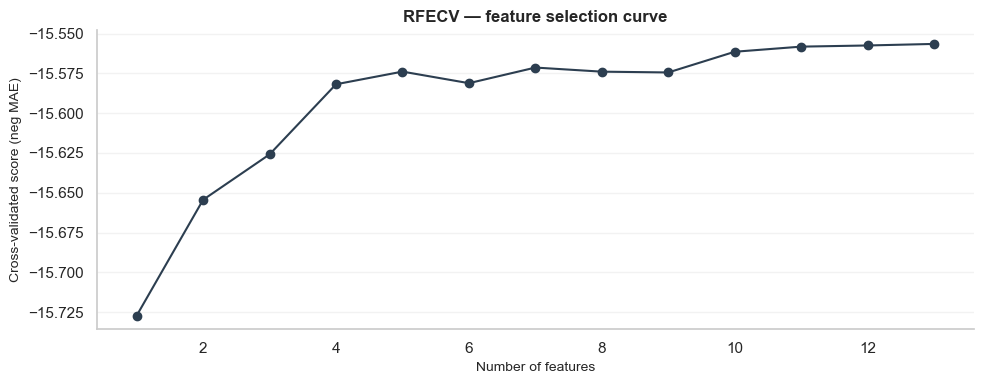

In [18]:
# Recursive Feature Elimination with Cross Validation
# scoring='neg_mean_absolute_error' is more discriminative than R² on this dataset
lr = LinearRegression()
rfecv = RFECV(estimator=lr, cv=5, scoring="neg_mean_absolute_error", min_features_to_select=1)
rfecv.fit(X_train_scaled, y_train)

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Features kept: {list(X_train_scaled.columns[rfecv.support_])}")

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
         rfecv.cv_results_['mean_test_score'], marker='o', color=COLOR_PRIMARY)
plt.xlabel("Number of features")
plt.ylabel("Cross-validated score (neg MAE)")
plt.title("RFECV — feature selection curve")
plt.tight_layout()
plt.show()


In [19]:
# Train Linear Regression on the selected features
selected = list(X_train_scaled.columns[rfecv.support_])
X_train_lr = X_train_scaled[selected]
X_test_lr  = X_test_scaled[selected]

lr = LinearRegression()
lr.fit(X_train_lr, y_train)

BEST_MODELS["Linear Regression"] = (lr, X_train_lr, X_test_lr)


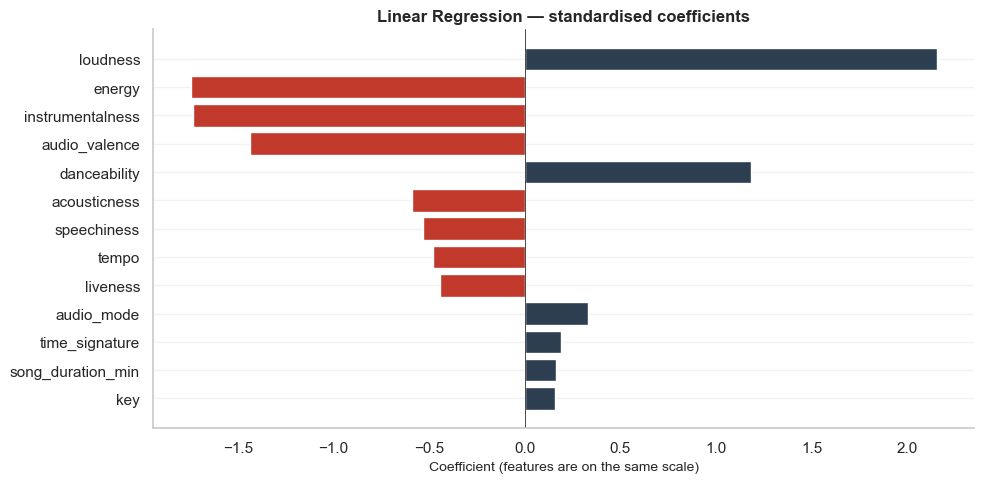

,Feature,Coefficient,Absolute
7,loudness,2.1527,2.1527
3,energy,-1.7462,1.7462
4,instrumentalness,-1.7318,1.7318
12,audio_valence,-1.4362,1.4362
2,danceability,1.1839,1.1839
1,acousticness,-0.5913,0.5913
9,speechiness,-0.5324,0.5324
10,tempo,-0.4783,0.4783
6,liveness,-0.4441,0.4441
8,audio_mode,0.3296,0.3296


In [20]:
# Standardised coefficients — since features were StandardScaled, coefficient
# magnitudes are directly comparable and can be read as feature importance.
coef_df = (pd.DataFrame({"Feature": selected, "Coefficient": lr.coef_})
           .assign(Absolute=lambda d: d["Coefficient"].abs())
           .sort_values("Absolute", ascending=False))

plt.figure(figsize=(10, 5))
colors = [COLOR_ACCENT if c < 0 else COLOR_PRIMARY for c in coef_df["Coefficient"]]
plt.barh(coef_df["Feature"][::-1], coef_df["Coefficient"][::-1], color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.5)
plt.title("Linear Regression — standardised coefficients")
plt.xlabel("Coefficient (features are on the same scale)")
plt.tight_layout()
plt.show()

coef_df.round(4)


**Note.** Because the features were standardised before fitting, the coefficients above can be compared directly. Positive coefficients (blue) push predicted popularity up as the feature increases; negative coefficients (red) push it down. The magnitude gives the effect size of a one-standard-deviation change in the feature.

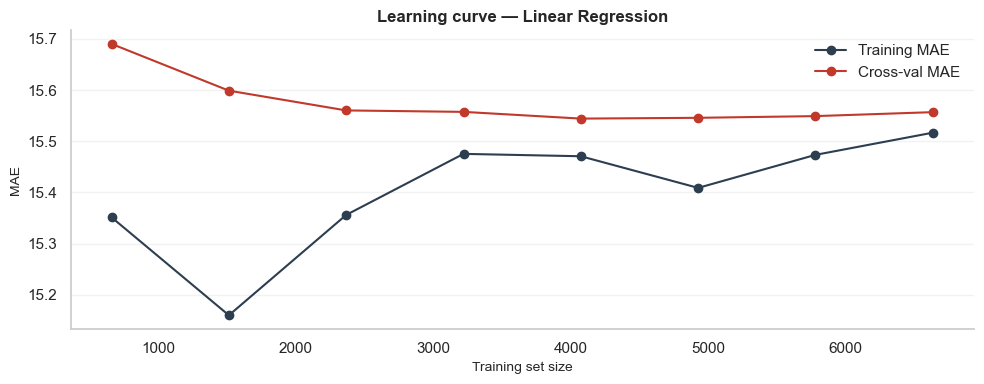

In [21]:
# Learning curve — training vs cross-validation MAE
from sklearn.model_selection import learning_curve

sizes = np.linspace(0.1, 1.0, 8)
train_sizes, train_scores, val_scores = learning_curve(
    LinearRegression(), X_train_lr, y_train, cv=5,
    scoring="neg_mean_absolute_error", train_sizes=sizes, n_jobs=-1
)
train_mae = -train_scores.mean(axis=1)
val_mae   = -val_scores.mean(axis=1)

plt.figure(figsize=(10, 4))
plt.plot(train_sizes, train_mae, marker="o", color=COLOR_PRIMARY, label="Training MAE")
plt.plot(train_sizes, val_mae,   marker="o", color=COLOR_ACCENT,  label="Cross-val MAE")
plt.xlabel("Training set size")
plt.ylabel("MAE")
plt.title("Learning curve — Linear Regression")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


#### Evaluation — Linear Regression


=== Linear Regression ===
  Measure   Train    Test
      MAE 15.5207 15.3343
     RMSE 19.4610 19.2322
       R²  0.0265  0.0018
MAX Error 54.8169 91.6965


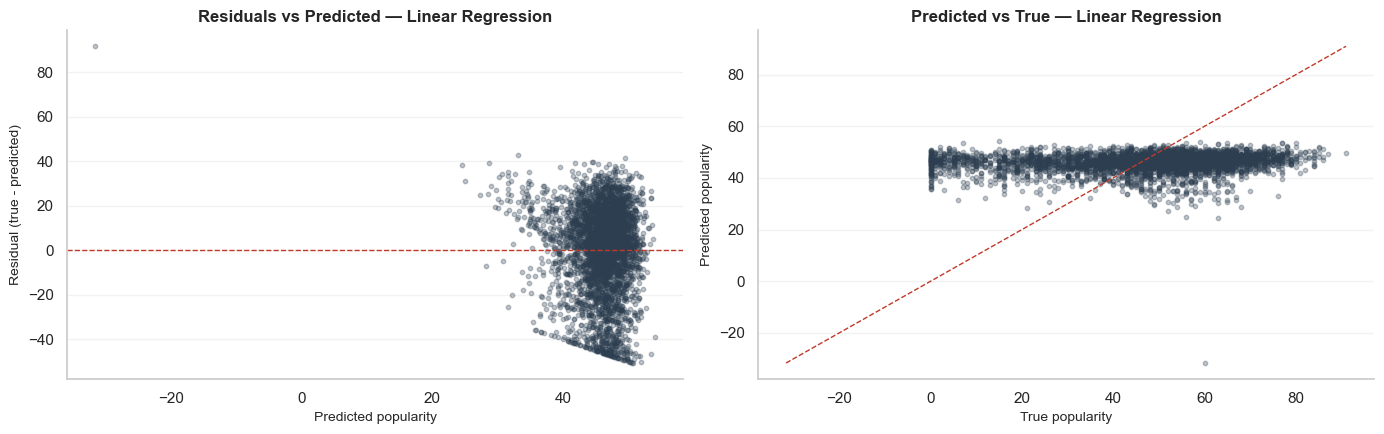

In [22]:
performance_table(lr, "Linear Regression", X_train_lr, y_train, X_test_lr, y_test)
plot_residuals_and_predicted(lr, "Linear Regression", X_test_lr, y_test)


**Note.** Train and test MAE are very close (indicating no overfitting), but the R² is very low. This is the signature of underfitting on a genuinely hard problem: the linear combination of audio features simply does not explain most of the variance in popularity. The residuals plot confirms this — residuals fan out for predicted popularity above 50, which means the model systematically underpredicts hits.

### Decision Tree Regressor

The Decision Tree is prone to overfitting when left with its default (unlimited depth). Hyperparameters are tuned with `GridSearchCV`.

In [23]:
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_leaf": [10, 25, 50, 100],
    "min_samples_split": [2, 10],
}

grid_tree = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid=param_grid, cv=5, scoring="neg_mean_absolute_error",
    n_jobs=-1, verbose=1,
)
grid_tree.fit(X_train_scaled, y_train)

print("Best parameters:", grid_tree.best_params_)
print(f"Best CV MAE: {-grid_tree.best_score_:.4f}")

best_tree = grid_tree.best_estimator_
BEST_MODELS["Decision Tree"] = (best_tree, X_train_scaled, X_test_scaled)


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters: {'max_depth': 5, 'min_samples_leaf': 100, 'min_samples_split': 2}
Best CV MAE: 15.5854


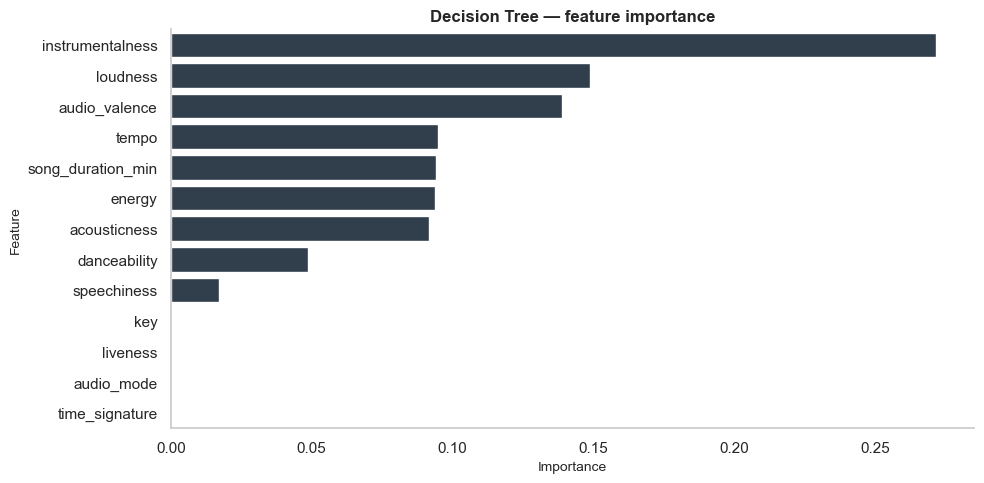

,Feature,Importance
4,instrumentalness,0.2716
7,loudness,0.1490
12,audio_valence,0.1389
10,tempo,0.0950
0,song_duration_min,0.0941
3,energy,0.0938
1,acousticness,0.0917
2,danceability,0.0489
9,speechiness,0.0171
5,key,0.0000


In [24]:
# Feature importance from the tuned tree
importances = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": best_tree.feature_importances_,
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importances, x="Importance", y="Feature", color=COLOR_PRIMARY)
plt.title("Decision Tree — feature importance")
plt.tight_layout()
plt.show()

importances.round(4)


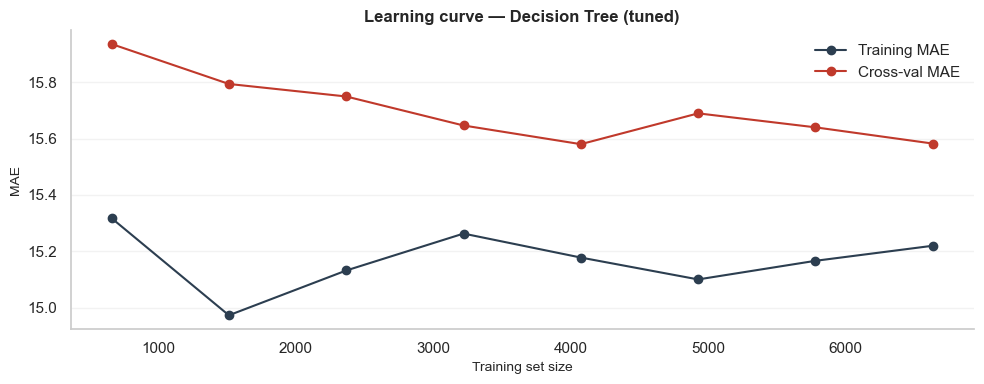

In [25]:
# Learning curve for the tuned tree
train_sizes, train_scores, val_scores = learning_curve(
    best_tree, X_train_scaled, y_train, cv=5,
    scoring="neg_mean_absolute_error",
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1,
)
train_mae = -train_scores.mean(axis=1)
val_mae   = -val_scores.mean(axis=1)

plt.figure(figsize=(10, 4))
plt.plot(train_sizes, train_mae, marker="o", color=COLOR_PRIMARY, label="Training MAE")
plt.plot(train_sizes, val_mae,   marker="o", color=COLOR_ACCENT,  label="Cross-val MAE")
plt.xlabel("Training set size")
plt.ylabel("MAE")
plt.title("Learning curve — Decision Tree (tuned)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


#### Evaluation — Decision Tree


=== Decision Tree (tuned) ===
  Measure   Train    Test
      MAE 15.2097 15.1663
     RMSE 19.1085 19.0743
       R²  0.0614  0.0181
MAX Error 56.4698 55.5446


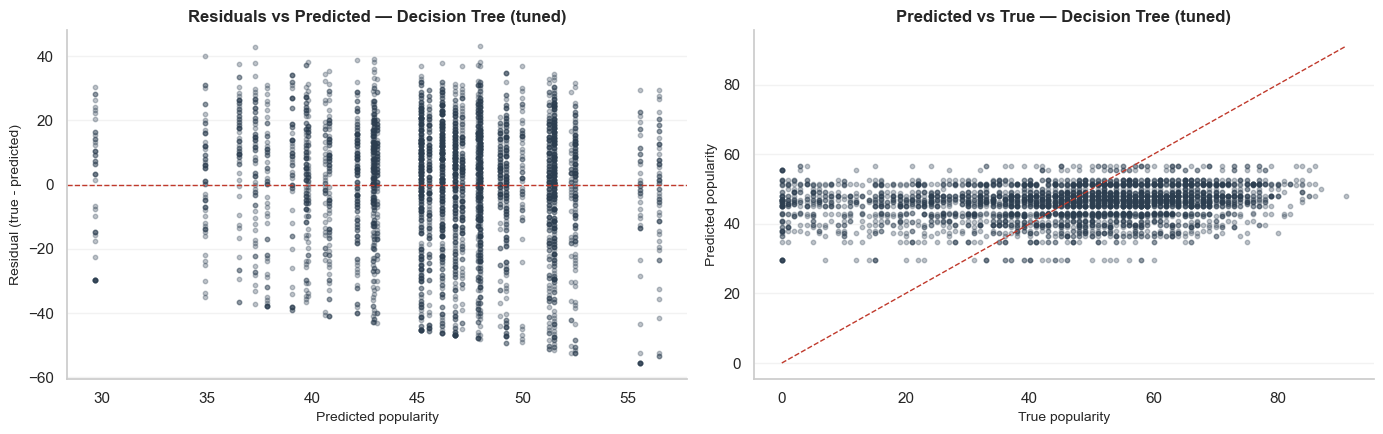

In [26]:
performance_table(best_tree, "Decision Tree (tuned)",
                  X_train_scaled, y_train, X_test_scaled, y_test)
plot_residuals_and_predicted(best_tree, "Decision Tree (tuned)", X_test_scaled, y_test)


**Note.** With the tree limited by `max_depth` and `min_samples_leaf`, training and test MAE stay close to each other. Compare this to the default `DecisionTreeRegressor()` (no regularisation), where the training MAE would drop to zero (the tree memorises the data) while the test MAE stays far higher — the classic overfitting signature.

### MLPRegressor (Linear Neural Network)

A multi-layer perceptron, from the same family covered in the class as "linear neural networks". The scaled features from earlier are essential here — neural networks need standardised inputs to converge well.

In [27]:
# A small MLP: two hidden layers, ReLU activation, Adam optimiser
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=RANDOM_STATE,
)
mlp.fit(X_train_scaled, y_train)

BEST_MODELS["MLP Regressor"] = (mlp, X_train_scaled, X_test_scaled)
print(f"Iterations to convergence: {mlp.n_iter_}")


Iterations to convergence: 87


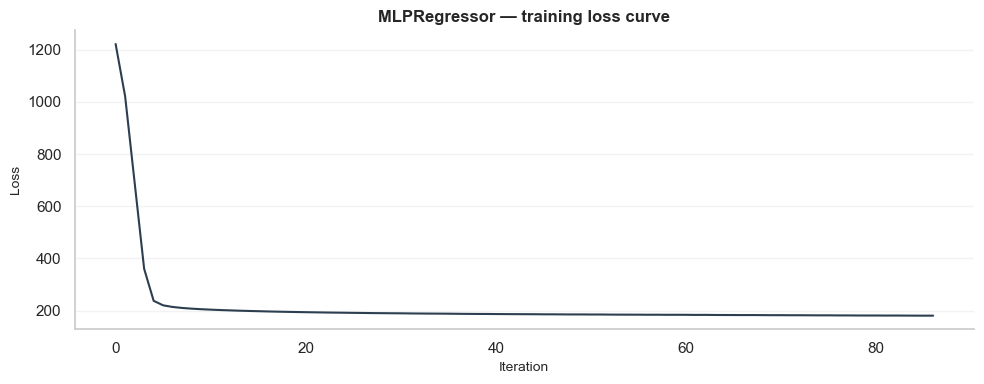

In [28]:
# Loss curve during training
plt.figure(figsize=(10, 4))
plt.plot(mlp.loss_curve_, color=COLOR_PRIMARY)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("MLPRegressor — training loss curve")
plt.tight_layout()
plt.show()


#### Evaluation — MLPRegressor


=== MLPRegressor ===
  Measure   Train     Test
      MAE 15.1963  15.3066
     RMSE 19.0309  19.3941
       R²  0.0690  -0.0151
MAX Error 58.0814 180.0564


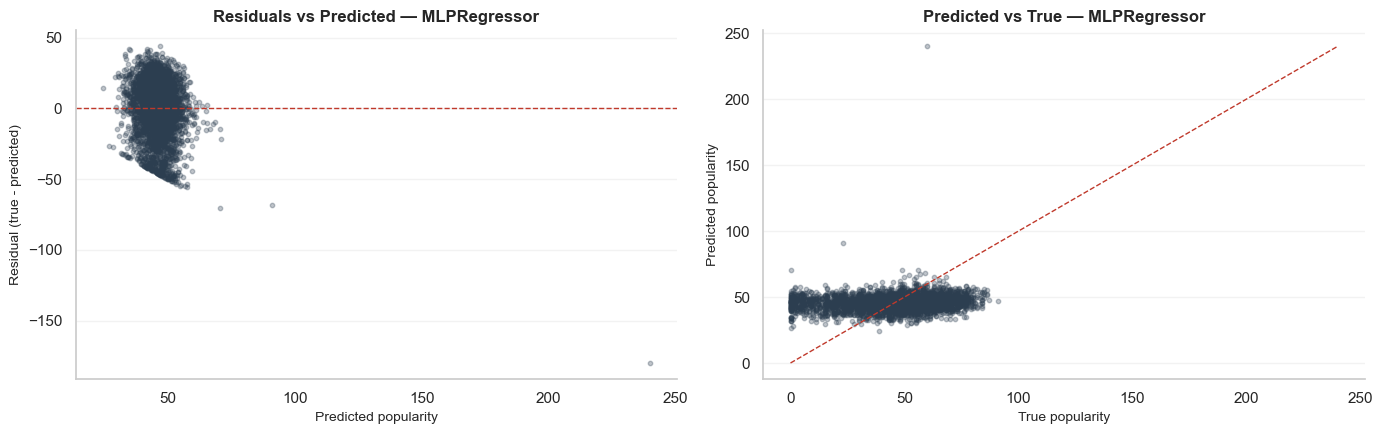

In [29]:
performance_table(mlp, "MLPRegressor",
                  X_train_scaled, y_train, X_test_scaled, y_test)
plot_residuals_and_predicted(mlp, "MLPRegressor", X_test_scaled, y_test)


**Note.** Two red flags here:

- **Test R² is slightly negative.** Negative R² means the model predicts worse on the test set than always guessing the mean of the target. That is a sign the network is fitting patterns in the training set that do not generalise.
- **Max Error reaches around 180** on a scale that only goes from 0 to 100. Unlike Linear Regression and the Decision Tree, an MLP has no built-in constraint on its output range. On a few points it extrapolates well outside the possible values of `song_popularity`.

Both issues point to the same underlying problem: the audio features carry very little signal about popularity, and the MLP has more freedom than the signal justifies. A regularised MLP (stronger `alpha`, smaller hidden layers) or a simpler model would behave better here. For this project we keep the vanilla MLP to match the "linear neural network" implementation taught in class and let the diagnostic speak for itself.


## Evaluation

### Model comparison — test set

In [30]:
# Consolidated test-set results for the 3 tuned models
def test_only_metrics(model, X_te, y_te):
    y_pred = model.predict(X_te)
    return {
        "MAE": mean_absolute_error(y_te, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_te, y_pred)),
        "R²": r2_score(y_te, y_pred),
        "MAX Error": max_error(y_te, y_pred),
    }

comparison = pd.DataFrame(
    {name: test_only_metrics(model, X_te, y_test)
     for name, (model, _, X_te) in BEST_MODELS.items()}
).T.round(4)

comparison


,MAE,RMSE,R²,MAX Error
Linear Regression,15.3343,19.2322,0.0018,91.6965
Decision Tree,15.1663,19.0743,0.0181,55.5446
MLP Regressor,15.3066,19.3941,-0.0151,180.0564


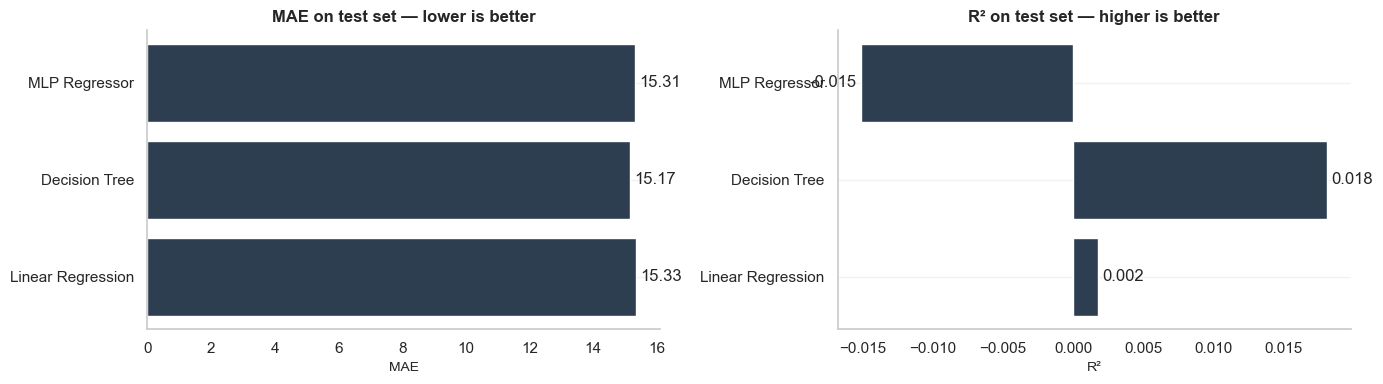

In [31]:
# Visual comparison across MAE and R²
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].barh(comparison.index, comparison["MAE"], color=COLOR_PRIMARY)
axes[0].set_title("MAE on test set — lower is better")
axes[0].set_xlabel("MAE")
axes[0].bar_label(axes[0].containers[0], fmt="%.2f", padding=3)

axes[1].barh(comparison.index, comparison["R²"], color=COLOR_PRIMARY)
axes[1].set_title("R² on test set — higher is better")
axes[1].set_xlabel("R²")
axes[1].bar_label(axes[1].containers[0], fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()


**Note.** All three models sit within one MAE point of each other on the test set, and the absolute error is around 15 popularity points on the 0-100 scale. R² tells a sharper story:

- **Linear Regression** — MAE 15.33, R² ≈ 0.002. Near-zero R² confirms the linear underfitting that the correlation heatmap already predicted.
- **Decision Tree (tuned)** — MAE 15.17, R² ≈ 0.018. Small improvement over Linear Regression thanks to a few non-linear splits (`instrumentalness`, `loudness`, `audio_valence` account for most of the tree's decisions). Training and cross-validation MAE stay within 0.4 points of each other, meaning the tuning kept overfitting under control.
- **MLPRegressor** — MAE 15.31, but R² is **negative** (≈ -0.015) and the Max Error reaches ~180 on a 0-100 scale. Negative R² means the network is worse than always predicting the mean of the target; the extreme Max Error means it occasionally outputs values outside the possible range of the target. The signal is too weak for the added flexibility of a neural network to help.

**Choice for deployment: tuned Decision Tree.** It has the lowest MAE, the highest R² of the three, no exploding predictions, and produces an interpretable feature ranking. The natural ceiling of any of the three models on this dataset is around R² ≈ 0.02 on unseen data — the ceiling is set by the data (audio features do not capture marketing, notoriety, or timing), not by the algorithm choice.


## Deployment

In [32]:
# Choose the model that goes to production
FINAL_MODEL, X_train_final, X_test_final = BEST_MODELS["Decision Tree"]

# Score the test set
y_pred_final = FINAL_MODEL.predict(X_test_final)

# Save alongside the true value for review
predictions = pd.DataFrame({
    "true_popularity": y_test.values,
    "predicted_popularity": y_pred_final,
}, index=y_test.index)

out_path = REPORT_DIR / "predictions.csv"
predictions.to_csv(out_path)
print(f"Predictions saved: {out_path}")
predictions.head(10)


Predictions saved: ../reports/predictions.csv


,true_popularity,predicted_popularity
6275,10,39.706140
4357,49,39.035398
12644,56,46.760949
2661,32,45.139756
14919,58,45.139756
11955,57,52.470270
17561,48,56.469799
6225,70,51.479050
2791,41,42.127389
2835,1,40.608333


In [33]:
# Persist the model and the scaler for reuse
model_path  = MODEL_DIR / "best_model_decision_tree.joblib"
scaler_path = MODEL_DIR / "standard_scaler.joblib"

dump(FINAL_MODEL, model_path)
dump(scaler, scaler_path)

print(f"Model saved at: {model_path}")
print(f"Scaler saved at: {scaler_path}")
print("\nTo reuse in another script:")
print(">>> from joblib import load")
print(">>> model  = load('models/best_model_decision_tree.joblib')")
print(">>> scaler = load('models/standard_scaler.joblib')")


Model saved at: ../models/best_model_decision_tree.joblib
Scaler saved at: ../models/standard_scaler.joblib

To reuse in another script:
>>> from joblib import load
>>> model  = load('models/best_model_decision_tree.joblib')
>>> scaler = load('models/standard_scaler.joblib')


---
## Scope and limitations

The dataset contains only audio features. Song popularity in the real world is driven by many things this dataset does not capture: artist notoriety, marketing investment, playlist inclusion, streaming platform algorithms, release timing, and cultural context. Any of the three models here reaches a natural ceiling around R² ≈ 0.02 on the test set — this is a property of the data, not of the algorithms.

`loudness` and `energy` are highly correlated (~0.76). In the linear model, this multicollinearity distorts the individual coefficients. A production version would either drop one of them or use a regularised regression that handles collinearity gracefully.

The songs with `song_popularity = 0` behave differently from the main distribution — they are likely unrated or unreleased tracks. Treating this as a two-stage problem (first predict "rated / unrated", then predict popularity conditional on rated) would probably improve overall accuracy but was out of scope for this class assignment.

The main finding of the project is honest: audio features alone do not explain what makes a song popular. The three models converge on a low-R² answer, and the modest feature-importance rankings (instrumentalness, loudness, audio_valence at the top of the tree) offer directional hints, not deterministic rules. For a marketing budget decision, the prediction should be one input among several — never the sole determinant.
